# 递归 Burg 变体 — 固定频率 Vocoder 对比测试

## 问题

在固定频率（尤其高频如 880Hz）δ 串载波 Vocoder 中，标准的递归 Burg 算法（`eps` 初始化）合成结果噪声偏大。

## 目标

对比不同递归 Burg **初始化策略**对高频 Vocoder 噪声的抑制效果，寻找最优参数组合。

**遗忘时间固定 τ = 10ms**（平衡收敛速度与稳态误差）。

## 测试变体

### 初始化策略（B(0) 初始化方式）

| 策略 | 描述 |
|------|------|
| `eps` | B(0) = ε（默认，小常数 1e-6） |
| `one` | B(0) = 1.0（固定较大值） |
| `var` | B(0) = σ²(x)（用信号方差） |
| `init_frame` | 先用前 N_init 样本估算 B(0) |

## 参考

- [recursive_burg_vocoder.ipynb](recursive_burg_vocoder.ipynb) — 原 Vocoder 测试
- [recursive_burg_study.ipynb](recursive_burg_study.ipynb) — 递归 Burg 初始化策略研究


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf
from scipy.signal import freqz, lfilter, spectrogram
from IPython.display import Audio, display
import os

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei"]
plt.rcParams["axes.unicode_minus"] = False
np.random.seed(42)

print("库导入完成")


库导入完成


---
## 1. 读取 wormhole.wav 前 1 秒


In [7]:
# ------------------------------------------------------------
# 读取 wormhole.wav 前 1 秒
# ------------------------------------------------------------
WAV_PATH = r"c:\Users\Kawai\Desktop\a5632645\qwqdsp\qwqdsp\tests\work_dir\input\wormhole.wav"
x_full, fs = sf.read(WAV_PATH)

# 转为单声道
if x_full.ndim > 1:
    x_full = x_full[:, 0]

# 截取前 1 秒
N = int(1.0 * fs)
x = x_full[:N].copy()
t = np.arange(N) / fs

print(f"采样率: {fs} Hz")
print(f"长度: {N} 样本 ({N/fs:.2f} 秒)")
print(f"信号范围: [{x.min():.4f}, {x.max():.4f}]")

# 预加重
pre_emph = 0.97
x_pre = np.append(x[0], x[1:] - pre_emph * x[:-1])


采样率: 48000 Hz
长度: 48000 样本 (1.00 秒)
信号范围: [-0.5369, 0.4222]


---
## 2. 算法函数定义


In [8]:
# ------------------------------------------------------------
# 2a. 分块 Burg（参考基准）
# ------------------------------------------------------------
def block_burg(x, order):
    """标准分块 Burg 法，返回 LPC 系数、残差、反射系数"""
    N = len(x)
    f = x.copy().astype(np.float64)
    b = x.copy().astype(np.float64)
    k = np.zeros(order)
    a = np.array([1.0])
    for m in range(order):
        num = 2.0 * np.sum(f[m+1:] * b[m:N-1])
        den = np.sum(f[m+1:]**2 + b[m:N-1]**2)
        k[m] = -num / den if den > 1e-30 else 0.0
        f_next = f.copy()
        b_next = b.copy()
        f_next[m+1:] = f[m+1:] + k[m] * b[m:N-1]
        b_next[m+1:] = b[m:N-1] + k[m] * f[m+1:]
        f, b = f_next, b_next
        a = np.pad(a, (0, 1), mode='constant')
        a_prev = a.copy()
        a[-1] = k[m]
        for i in range(1, m + 1):
            a[i] = a_prev[i] + k[m] * a_prev[m + 1 - i]
    return a, f.copy(), k


# ------------------------------------------------------------
# 2b. Levinson 递推：反射系数 -> LPC 系数
# ------------------------------------------------------------
def levinson_from_k(k):
    """从反射系数计算 LPC 系数 [1, a1, ..., aP]"""
    P = len(k)
    a = np.ones(P + 1)
    for m in range(P):
        k_m = k[m]
        a_prev = a.copy()
        a[m + 1] = k_m
        for i in range(1, m + 1):
            a[i] = a_prev[i] + k_m * a_prev[m - i + 1]
    return a


# ------------------------------------------------------------
# 2c. 时变 LPC 合成滤波器（逐样本递推）
# ------------------------------------------------------------
def lpc_synth_tv(excitation, a_history):
    """
    时变 LPC 合成滤波器：每样本使用不同的 LPC 系数。

    参数:
        excitation: 激励信号 (N,)
        a_history: LPC 系数历史 (N, P+1)，每行 [1, a1, ..., aP]
    返回:
        合成信号 (N,)
    """
    N = len(excitation)
    P = a_history.shape[1] - 1
    y = np.zeros(N, dtype=np.float64)
    for n in range(N):
        a = a_history[n]
        y[n] = excitation[n]
        for m in range(1, P + 1):
            if n >= m:
                y[n] -= a[m] * y[n - m]
    return y


# ------------------------------------------------------------
# 2d. 递归 Burg（多初始化策略）
# ------------------------------------------------------------
def recursive_burg_init(x, order, lam=0.995, init_mode='eps', init_val=1e-6):
    """
    支持不同初始化策略的递归 Burg 法。

    初始化策略:
        'eps':        B(0) = ε（小常数，默认）
        'one':        B(0) = 1.0（固定较大值）
        'var':        B(0) = σ²(x)（用信号方差）
        'init_frame': 先用前 init_len 样本估算 B(0)
    """
    N = len(x)
    dtype = np.float64
    f_curr = np.zeros(order + 1, dtype=dtype)
    b_prev_arr = np.zeros(order + 1, dtype=dtype)
    b_curr = np.zeros(order + 1, dtype=dtype)
    A = np.zeros(order, dtype=dtype)
    k = np.zeros(order, dtype=dtype)
    k_history = np.zeros((N, order), dtype=dtype)
    e = np.zeros(N, dtype=dtype)

    if init_mode == 'eps':
        B = np.full(order, init_val, dtype=dtype)
    elif init_mode == 'var':
        sigma2 = np.var(x[:200]) + 1e-30
        B = np.full(order, sigma2, dtype=dtype)
    elif init_mode == 'one':
        B = np.ones(order, dtype=dtype)
    elif init_mode == 'init_frame':
        init_len = min(256, N // 4)
        sigma2 = np.var(x[:init_len]) + 1e-30
        B = np.full(order, sigma2 / (1 - lam**init_len), dtype=dtype)
    else:
        B = np.full(order, init_val, dtype=dtype)

    for t in range(N):
        f_curr[0] = x[t]
        b_curr[0] = x[t]
        for m in range(order):
            f_m1_t = f_curr[m]
            b_m1_t1 = b_prev_arr[m]
            A[m] = lam * A[m] + f_m1_t * b_m1_t1
            B[m] = lam * B[m] + f_m1_t**2 + b_m1_t1**2
            k[m] = -2.0 * A[m] / B[m] if B[m] > 1e-30 else 0.0
            k[m] = np.clip(k[m], -0.999, 0.999)
            f_curr[m + 1] = f_m1_t + k[m] * b_m1_t1
            b_curr[m + 1] = b_m1_t1 + k[m] * f_m1_t
        k_history[t] = k.copy()
        e[t] = f_curr[order]
        b_prev_arr[:order] = b_curr[:order]
    return k_history, e


# ------------------------------------------------------------
# 2e. 固定频率 δ 串生成
# ------------------------------------------------------------
def fixed_freq_delta_train(freq_hz, n_samples, fs):
    """生成固定频率的 δ 脉冲串"""
    period = int(fs / freq_hz)
    exc = np.zeros(n_samples)
    exc[::period] = 1.0
    return exc


def fixed_freq_excitation(freq_hz, n_samples, fs, frame_energy, frame_len, hop_len):
    """生成幅度包络对齐的固定频率 δ 串"""
    exc = fixed_freq_delta_train(freq_hz, n_samples, fs)
    win = np.hanning(frame_len)
    n_frames = 1 + (n_samples - frame_len) // hop_len
    exc_env = np.zeros(n_samples)
    for idx in range(n_frames):
        s = idx * hop_len
        e_frame = min(s + frame_len, n_samples)
        frame_len_actual = e_frame - s
        seg = slice(s, e_frame)
        frame_exc = exc[seg].copy()
        rms_target = frame_energy[idx]
        rms_exc = np.sqrt(np.mean(frame_exc**2) + 1e-30)
        if rms_exc > 1e-30 and rms_target > 1e-30:
            frame_exc *= rms_target / rms_exc
        exc_env[seg] += frame_exc * win[:frame_len_actual]
    return exc_env


def lpc_envelope(a, fs, n_fft=4096):
    """从 LPC 系数计算频谱包络（dB）"""
    w, h = freqz(1.0, a, worN=n_fft, fs=fs)
    env_db = 20.0 * np.log10(np.abs(h) + 1e-30)
    return w, env_db


print("所有算法函数定义完成")


所有算法函数定义完成


---
## 3. 参数设置与参考分析


In [9]:
# ------------------------------------------------------------
# 3a. 参数
# ------------------------------------------------------------
P = 36              # LPC 阶数
frame_ms = 30       # 帧长 30ms（分块 Burg + 幅度包络用）
hop_ms = 10         # 帧移 10ms
frame_len = int(frame_ms * fs / 1000)
hop_len = int(hop_ms * fs / 1000)
n_frames = 1 + (N - frame_len) // hop_len

print(f"LPC 阶数: P = {P}")
print(f"帧长: {frame_len} 采样 ({frame_ms}ms)")
print(f"帧移: {hop_len} 采样 ({hop_ms}ms)")
print(f"总帧数: {n_frames}")


# ------------------------------------------------------------
# 3b. 分块 Burg LPC 分析（参考基准）
# ------------------------------------------------------------
a_block_frames = np.zeros((n_frames, P + 1))
k_block_frames = np.zeros((n_frames, P))
win = np.hanning(frame_len)

for idx in range(n_frames):
    s = idx * hop_len
    frame = x_pre[s:s + frame_len] * win
    a_f, e_f, k_f = block_burg(frame, P)
    a_block_frames[idx] = a_f
    k_block_frames[idx] = k_f

print(f"分块 Burg LPC 分析完成 ({n_frames} 帧)")


# ------------------------------------------------------------
# 3c. 计算原始信号帧 RMS（用于载波幅度包络）
# ------------------------------------------------------------
frame_rms = np.zeros(n_frames)
for idx in range(n_frames):
    s = idx * hop_len
    e_frame = min(s + frame_len, N)
    frame_signal = x[s:e_frame]
    frame_rms[idx] = np.sqrt(np.mean(frame_signal**2) + 1e-30)

print(f"帧 RMS 范围: [{frame_rms.min():.6f}, {frame_rms.max():.6f}]")


# ------------------------------------------------------------
# 3d. 分块 Burg 固定频率载波合成（参考基准）
# ------------------------------------------------------------
def block_burg_synth(excitation, a_block_frames, n_frames, frame_len, hop_len, win):
    """用分块 Burg LPC 系数做帧级合成（OLA）"""
    N = len(excitation)
    synth = np.zeros(N)
    for idx in range(n_frames):
        s = idx * hop_len
        e_frame = min(s + frame_len, N)
        frame_exc = excitation[s:e_frame].copy()
        a_frame = a_block_frames[idx]
        frame_synth = lfilter([1.0], a_frame, frame_exc)
        synth[s:e_frame] += frame_synth * win[:e_frame - s]
    return synth


print("参考分析完成")


LPC 阶数: P = 36
帧长: 1440 采样 (30ms)
帧移: 480 采样 (10ms)
总帧数: 98
分块 Burg LPC 分析完成 (98 帧)
帧 RMS 范围: [0.014711, 0.200503]
参考分析完成


---
## 4. 变体批量测试：各初始化策略 × 各遗忘时间


In [10]:
# ------------------------------------------------------------
# 4a. 测试配置
# ------------------------------------------------------------
# 初始化策略
init_strategies = {
    'eps (1e-6)':         ('eps', 1e-6),
    'one (B=1.0)':        ('one', 0),
    'var (σ²)':           ('var', 0),
    'init_frame':         ('init_frame', 0),
}

# 遗忘时间固定为 10ms
TAU_MS = 10
lam = np.exp(-1.0 / ((TAU_MS / 1000.0) * fs))

# 测试频率：选高频 880Hz（噪声最明显）+ 440Hz 作为对照
test_freqs = {
    "A4 (440 Hz)": 440.0,
    "A5 (880 Hz)": 880.0,
}

# 存储结果
results = {}  # {(freq_label, init_label): synth_signal}


# ------------------------------------------------------------
# 4b. 生成载波（各频率共用同一个固定频率载波）
# ------------------------------------------------------------
exc_carriers = {}
frame_rms_for_carrier = frame_rms
for label, freq in test_freqs.items():
    exc_carriers[label] = fixed_freq_excitation(
        freq, N, fs, frame_rms_for_carrier, frame_len, hop_len)

print("固定频率载波生成完成")


# ------------------------------------------------------------
# 4c. 分块 Burg 参考合成
# ------------------------------------------------------------
synth_block = {}
for label, freq in test_freqs.items():
    synth_block[label] = block_burg_synth(
        exc_carriers[label], a_block_frames, n_frames, frame_len, hop_len, win)
print("分块 Burg 参考合成完成")


# ------------------------------------------------------------
# 4d. 批量运行所有变体（τ 固定 = 10ms）
# ------------------------------------------------------------
total = len(init_strategies) * len(test_freqs)
count = 0

for freq_label, freq_hz in test_freqs.items():
    exc = exc_carriers[freq_label]

    for init_label, (init_mode, init_val) in init_strategies.items():
        # 递归 Burg LPC 分析
        k_history, e_rec = recursive_burg_init(
            x_pre, P, lam=lam, init_mode=init_mode, init_val=init_val)

        # 转 LPC 系数
        a_history = np.zeros((N, P + 1))
        for n in range(N):
            a_history[n] = levinson_from_k(k_history[n])

        # 时变 LPC 合成
        synth = lpc_synth_tv(exc, a_history)

        key = (freq_label, init_label)
        results[key] = synth
        count += 1
        print(f"  进度: {count}/{total} — {freq_label} / {init_label}")

print(f"\n全部 {total} 个变体测试完成")

固定频率载波生成完成
分块 Burg 参考合成完成
  进度: 1/8 — A4 (440 Hz) / eps (1e-6)
  进度: 2/8 — A4 (440 Hz) / one (B=1.0)
  进度: 3/8 — A4 (440 Hz) / var (σ²)
  进度: 4/8 — A4 (440 Hz) / init_frame
  进度: 5/8 — A5 (880 Hz) / eps (1e-6)
  进度: 6/8 — A5 (880 Hz) / one (B=1.0)
  进度: 7/8 — A5 (880 Hz) / var (σ²)
  进度: 8/8 — A5 (880 Hz) / init_frame

全部 8 个变体测试完成


---
## 5. 波形对比（880Hz 高频载波）


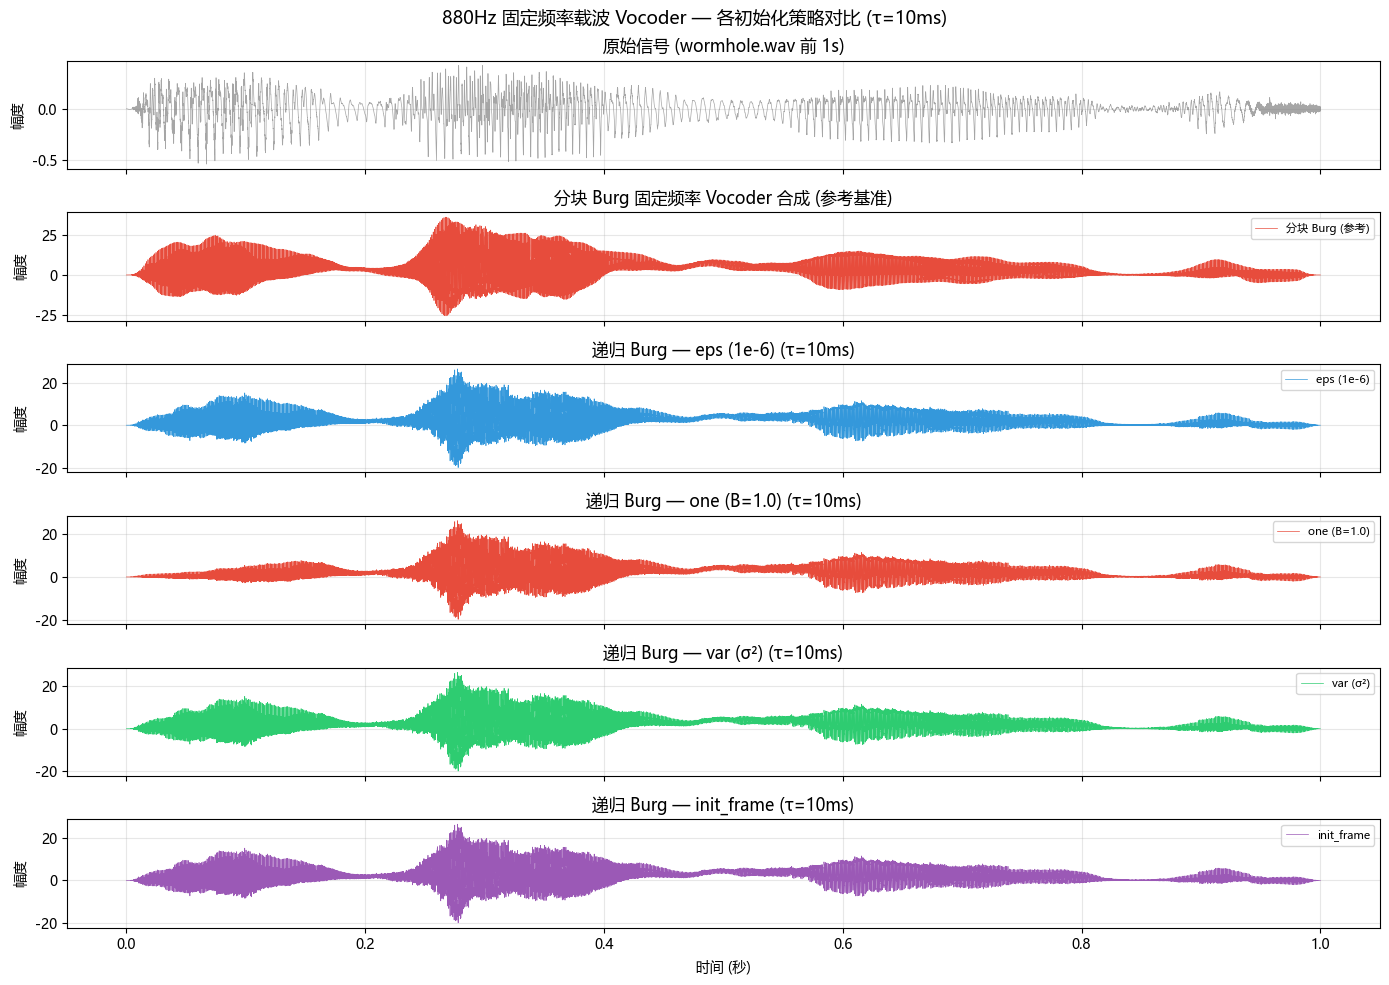

In [11]:
# ------------------------------------------------------------
# 5a. 880Hz 载波：各初始化策略波形对比（τ=10ms）
# ------------------------------------------------------------
freq_show = "A5 (880 Hz)"
n_init = len(init_strategies)
fig, axes = plt.subplots(n_init + 2, 1, figsize=(14, 10), sharex=True)

colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6']

# 原始信号
ax0 = axes[0]
ax0.plot(t, x, color='gray', linewidth=0.5, alpha=0.7)
ax0.set_ylabel('幅度')
ax0.set_title(f'原始信号 (wormhole.wav 前 1s)')
ax0.grid(True, alpha=0.3)

# 分块 Burg 参考
ax1 = axes[1]
ax1.plot(t, synth_block[freq_show], color='#e74c3c', linewidth=0.5,
         label='分块 Burg (参考)')
ax1.set_ylabel('幅度')
ax1.set_title('分块 Burg 固定频率 Vocoder 合成 (参考基准)')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=8)

# 各初始化策略
for i, (init_label, _) in enumerate(init_strategies.items()):
    ax = axes[i + 2]
    key = (freq_show, init_label)
    if key in results:
        ax.plot(t, results[key], linewidth=0.5, color=colors[i],
                label=f'{init_label}')
    ax.set_ylabel('幅度')
    ax.set_title(f'递归 Burg — {init_label} (τ=10ms)')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

axes[-1].set_xlabel('时间 (秒)')
plt.suptitle(f'880Hz 固定频率载波 Vocoder — 各初始化策略对比 (τ=10ms)', fontsize=13)
plt.tight_layout()
plt.show()


---
## 6. 语谱图对比（880Hz）


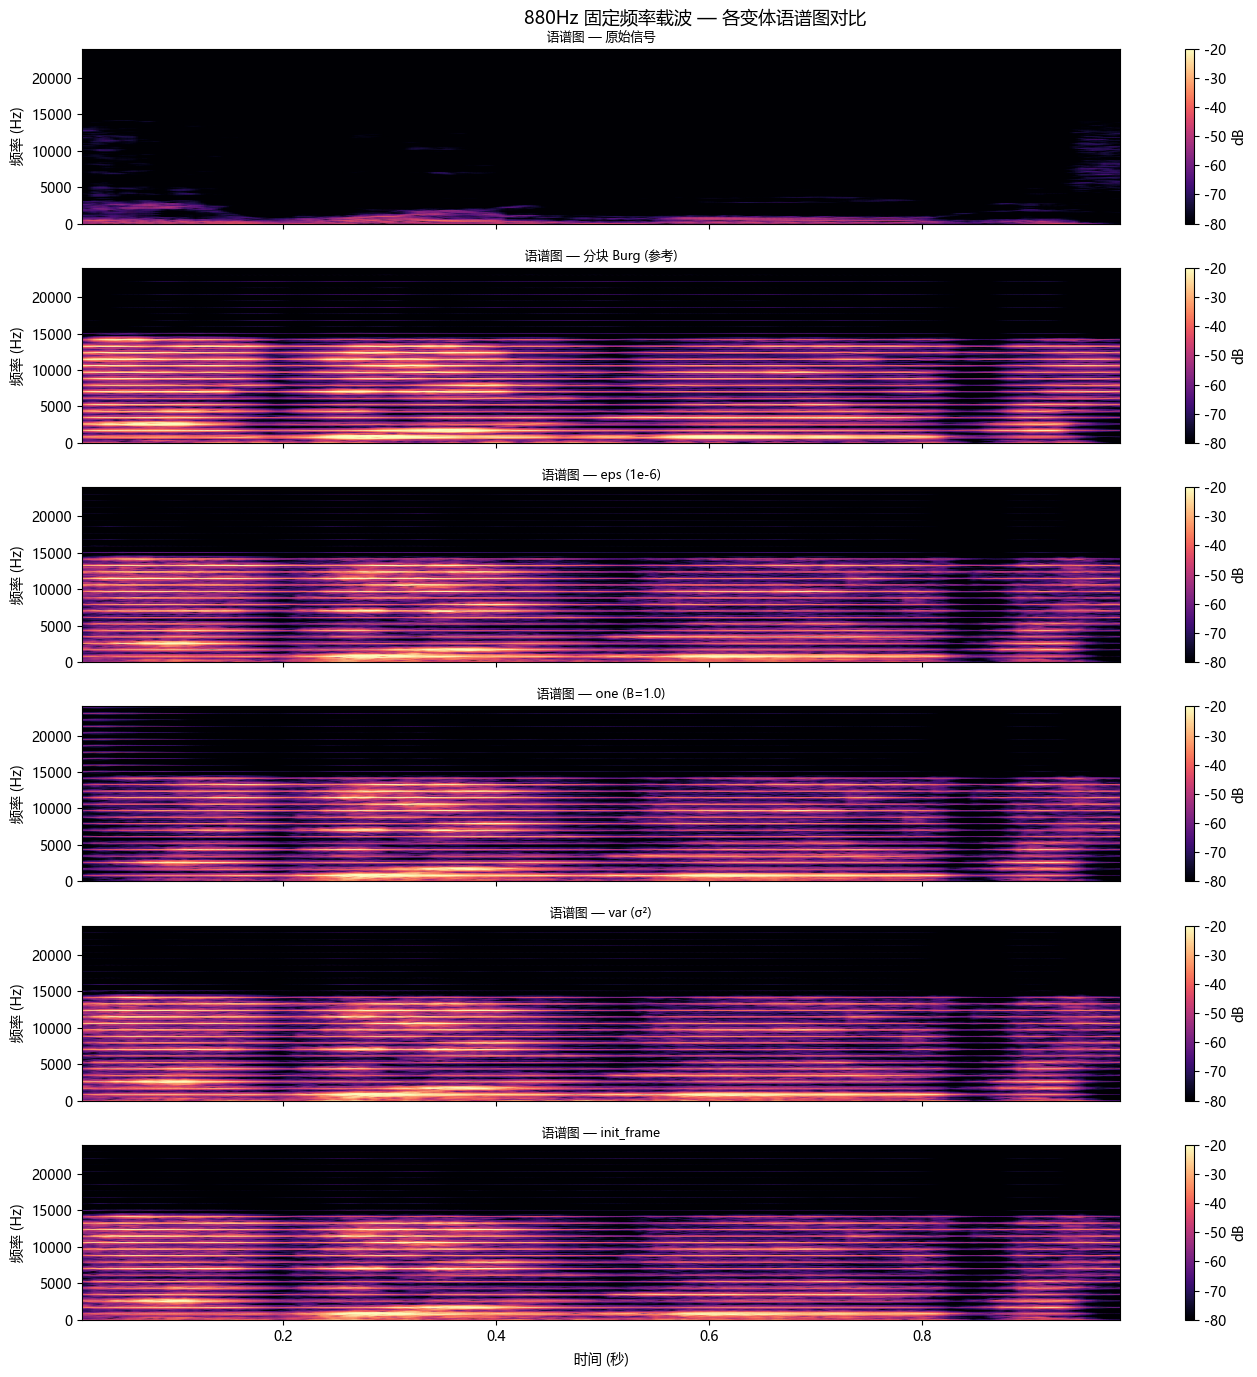

In [12]:
# ------------------------------------------------------------
# 6a. 880Hz 语谱图对比：选出最优组合
# ------------------------------------------------------------
n_fft_spec = 1024
hop_len_spec = 256
vmin_db, vmax_db = -80, -20

# 各策略变体展示（τ=10ms）
spec_show = [
    ("原始信号", x),
    ("分块 Burg (参考)", synth_block[freq_show]),
]

for init_label, _ in init_strategies.items():
    key = (freq_show, init_label)
    if key in results:
        spec_show.append((f"{init_label}", results[key]))

fig, axes = plt.subplots(len(spec_show), 1, figsize=(14, 14), sharex=True)

for idx, (label, signal) in enumerate(spec_show):
    ax = axes[idx]
    f_s, t_s, Sxx = spectrogram(signal, fs, nperseg=n_fft_spec,
                                 noverlap=n_fft_spec - hop_len_spec)
    Sxx_db = 10 * np.log10(Sxx + 1e-30)
    im = ax.pcolormesh(t_s, f_s, Sxx_db, shading='gouraud',
                       cmap='magma', vmin=vmin_db, vmax=vmax_db)
    ax.set_ylabel('频率 (Hz)')
    ax.set_title(f'语谱图 — {label}', fontsize=9)
    ax.set_ylim(0, fs / 2)
    fig.colorbar(im, ax=ax, label='dB')

axes[-1].set_xlabel('时间 (秒)')
plt.suptitle(f'880Hz 固定频率载波 — 各变体语谱图对比', fontsize=13)
plt.tight_layout()
plt.show()


---
## 7. 定量评价


In [13]:
# ------------------------------------------------------------
# 7a. 定量评价指标
# ------------------------------------------------------------
def compute_snr(original, reconstructed):
    noise = original - reconstructed
    snr = 10 * np.log10(np.sum(original**2) / (np.sum(noise**2) + 1e-30))
    return snr


def high_freq_snr(original, reconstructed, fs, cutoff=2000):
    """只计算高频段 [cutoff, fs/2] 的 SNR"""
    from scipy.signal import butter, sosfilt

    # 高通滤波
    sos = butter(4, cutoff, btype='high', fs=fs, output='sos')
    orig_hf = sosfilt(sos, original)
    recon_hf = sosfilt(sos, reconstructed)
    return compute_snr(orig_hf, recon_hf)


# ----- 对 880Hz 载波计算各变体 SNR -----
print(f"=== 880Hz 固定频率载波 — 各变体 SNR 对比 (τ=10ms) ===\n")
print(f"{'初始化策略':<18} {'SNR (dB)':<12} {'高频SNR (dB)':<15} {'分块差异':<12}")
print("-" * 57)

# 分块 Burg 的 SNR 作为参考
snr_block_ref = compute_snr(x, synth_block[freq_show])
hf_snr_block_ref = high_freq_snr(x, synth_block[freq_show], fs)
print(f"{'分块 Burg (参考)':<18} {snr_block_ref:<12.2f} {hf_snr_block_ref:<15.2f} {'-':<12}")

for init_label, _ in init_strategies.items():
    key = (freq_show, init_label)
    if key in results:
        snr_val = compute_snr(x, results[key])
        hf_snr = high_freq_snr(x, results[key], fs)
        diff = snr_val - snr_block_ref
        print(f"{init_label:<18} {snr_val:<12.2f} {hf_snr:<15.2f} {diff:<+12.2f}")


# ----- 按高频 SNR 排序 -----
print(f"\n=== 高频段 SNR 排名（880Hz 载波，>2kHz 频段）===")
rankings = []
for init_label, _ in init_strategies.items():
    key = (freq_show, init_label)
    if key in results:
        hf_snr = high_freq_snr(x, results[key], fs)
        rankings.append((hf_snr, init_label))

rankings.sort(reverse=True)
for i, (hf_snr, init_label) in enumerate(rankings):
    print(f"  {i+1}. {init_label:<18}  HF-SNR={hf_snr:.2f} dB")
print(f"\n  (参考) 分块 Burg  HF-SNR={hf_snr_block_ref:.2f} dB")


=== 880Hz 固定频率载波 — 各变体 SNR 对比 (τ=10ms) ===

初始化策略              SNR (dB)     高频SNR (dB)      分块差异        
---------------------------------------------------------
分块 Burg (参考)       -34.34       -47.31          -           
eps (1e-6)         -30.15       -42.54          +4.19       
one (B=1.0)        -29.75       -40.61          +4.59       
var (σ²)           -30.15       -42.54          +4.19       
init_frame         -30.15       -42.54          +4.19       

=== 高频段 SNR 排名（880Hz 载波，>2kHz 频段）===
  1. one (B=1.0)         HF-SNR=-40.61 dB
  2. init_frame          HF-SNR=-42.54 dB
  3. eps (1e-6)          HF-SNR=-42.54 dB
  4. var (σ²)            HF-SNR=-42.54 dB

  (参考) 分块 Burg  HF-SNR=-47.31 dB


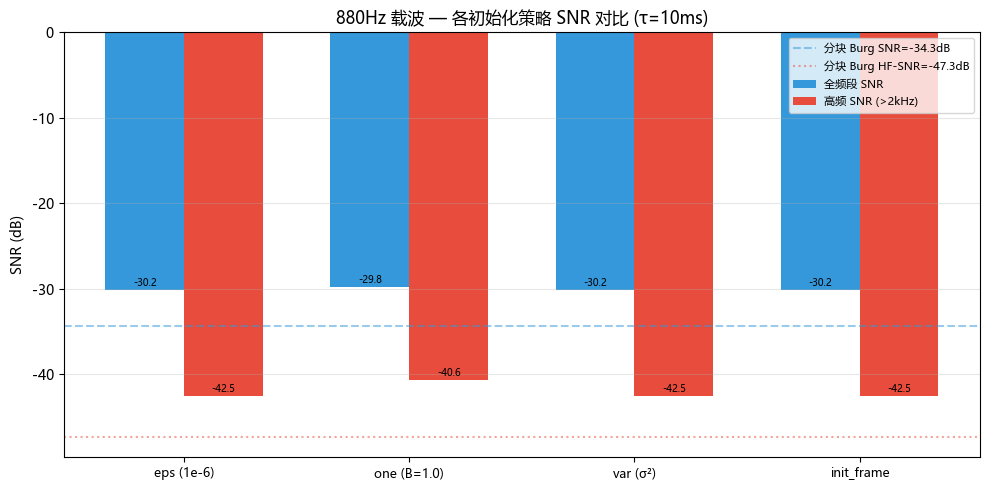

In [14]:
# ------------------------------------------------------------
# 7b. SNR 柱状图（各初始化策略对比）
# ------------------------------------------------------------
init_labels = list(init_strategies.keys())
snr_vals = []
hf_snr_vals = []

for init_label, _ in init_strategies.items():
    key = (freq_show, init_label)
    if key in results:
        snr_vals.append(compute_snr(x, results[key]))
        hf_snr_vals.append(high_freq_snr(x, results[key], fs))
    else:
        snr_vals.append(0)
        hf_snr_vals.append(0)

x_pos = np.arange(len(init_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bar1 = ax.bar(x_pos - width/2, snr_vals, width, label='全频段 SNR', color='#3498db')
bar2 = ax.bar(x_pos + width/2, hf_snr_vals, width, label='高频 SNR (>2kHz)', color='#e74c3c')

# 分块 Burg 参考线
ax.axhline(y=snr_block_ref, color='#3498db', linestyle='--', alpha=0.5,
           label=f'分块 Burg SNR={snr_block_ref:.1f}dB')
ax.axhline(y=hf_snr_block_ref, color='#e74c3c', linestyle=':', alpha=0.5,
           label=f'分块 Burg HF-SNR={hf_snr_block_ref:.1f}dB')

ax.set_xticks(x_pos)
ax.set_xticklabels(init_labels, fontsize=9)
ax.set_ylabel('SNR (dB)')
ax.set_title(f'880Hz 载波 — 各初始化策略 SNR 对比 (τ=10ms)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis='y')

# 在柱上标数值
for bar in bar1:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=7)
for bar in bar2:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=7)

plt.tight_layout()
plt.show()


---
## 8. 音频播放对比

> ⚠️ 以下单元格包含 `display(Audio(...))`，运行后会播放音频。
> 请在需要听音对比时手动运行。


In [15]:
# ------------------------------------------------------------
# 8a. 音频播放 — 各变体对比（880Hz 载波）
# ------------------------------------------------------------
print("原始信号（前 1 秒）:")
display(Audio(x, rate=fs))

print("\n分块 Burg (参考) — 880Hz 载波:")
synth_block_norm = synth_block[freq_show] / (np.max(np.abs(synth_block[freq_show])) + 1e-30)
display(Audio(synth_block_norm, rate=fs))

# 各初始化策略播放（τ=10ms）
for init_label, _ in init_strategies.items():
    key = (freq_show, init_label)
    if key in results:
        s = results[key]
        hf_s = high_freq_snr(x, s, fs)
        s_norm = s / (np.max(np.abs(s)) + 1e-30)
        print(f"\n{init_label} (HF-SNR={hf_s:.1f}dB) — 880Hz 载波:")
        display(Audio(s_norm, rate=fs))


原始信号（前 1 秒）:



分块 Burg (参考) — 880Hz 载波:



eps (1e-6) (HF-SNR=-42.5dB) — 880Hz 载波:



one (B=1.0) (HF-SNR=-40.6dB) — 880Hz 载波:



var (σ²) (HF-SNR=-42.5dB) — 880Hz 载波:



init_frame (HF-SNR=-42.5dB) — 880Hz 载波:
